# Notebook 02: Data Preparation & Client Partitioning

## Objectives

- Load CIFAR-10
- Apply preprocessing
- Create IID partitions
- Create Non-IID partitions
- Visualize client data distributions
- Save partitions for later federated learning experiments

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import random
from collections import Counter

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Random seed set to", SEED)

Random seed set to 42


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

print("Training:", len(trainset))
print("Testing :", len(testset))

100%|██████████| 170M/170M [58:01<00:00, 49.0kB/s]


Training: 50000
Testing : 10000


In [8]:
classes = trainset.classes

print("="*50)

for i, cls in enumerate(classes):
    print(i, cls)

print("="*50)

0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


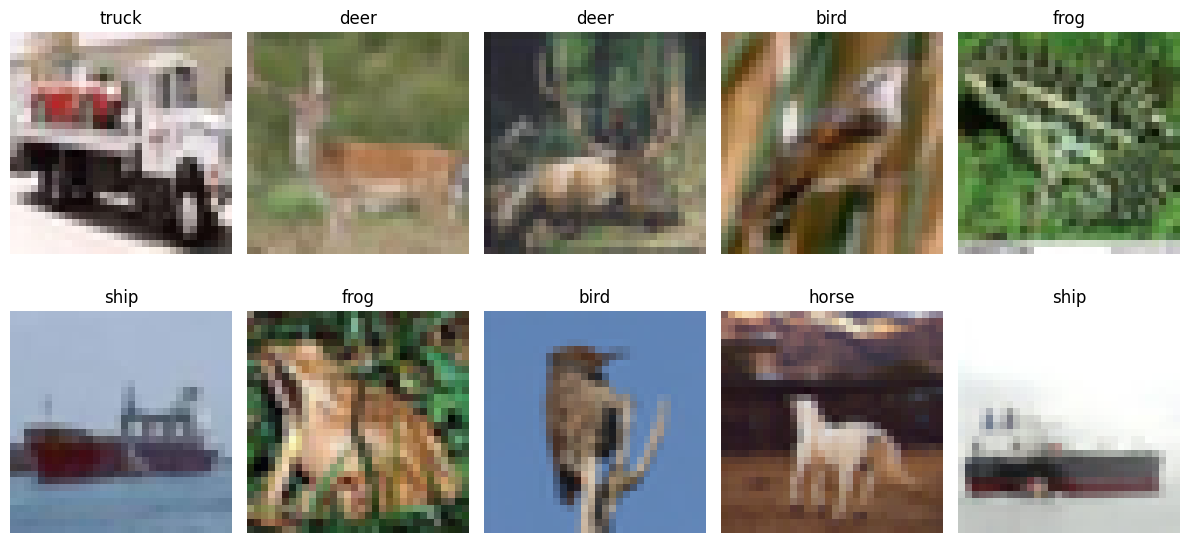

In [9]:
plt.figure(figsize=(12,6))

for i in range(10):

    image, label = trainset[random.randint(0,49999)]

    image = image.permute(1,2,0)

    image = image * torch.tensor((0.2023,0.1994,0.2010)) + torch.tensor((0.4914,0.4822,0.4465))

    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.title(classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CREATE IID CLIENT PARTITIONS
# ============================================================

NUM_CLIENTS = 10

# Total number of training samples
num_samples = len(trainset)

# Generate shuffled indices
indices = np.random.permutation(num_samples)

# Split equally among clients
iid_clients = np.array_split(indices, NUM_CLIENTS)

print("=" * 60)
print("IID CLIENT PARTITIONS CREATED")
print("=" * 60)

for i, client in enumerate(iid_clients):
    print(f"Client {i+1}: {len(client)} images")

IID CLIENT PARTITIONS CREATED
Client 1: 5000 images
Client 2: 5000 images
Client 3: 5000 images
Client 4: 5000 images
Client 5: 5000 images
Client 6: 5000 images
Client 7: 5000 images
Client 8: 5000 images
Client 9: 5000 images
Client 10: 5000 images


In [11]:
# ============================================================
# VERIFY IID CLASS DISTRIBUTION
# ============================================================

targets = np.array(trainset.targets)

client_distribution = []

for client in iid_clients:

    labels = targets[client]

    class_counts = [np.sum(labels == i) for i in range(10)]

    client_distribution.append(class_counts)

client_distribution = np.array(client_distribution)

print("Class distribution for each client:\n")

for i in range(NUM_CLIENTS):
    print(f"Client {i+1}: {client_distribution[i]}")

Class distribution for each client:

Client 1: [476 487 527 523 486 504 485 509 503 500]
Client 2: [497 492 503 500 447 511 511 485 514 540]
Client 3: [500 498 470 519 504 530 469 497 529 484]
Client 4: [500 502 509 499 507 488 475 502 499 519]
Client 5: [476 530 505 495 470 511 507 493 496 517]
Client 6: [505 518 502 496 529 487 519 493 472 479]
Client 7: [531 505 502 498 513 478 532 481 472 488]
Client 8: [505 479 489 503 533 487 469 494 511 530]
Client 9: [500 502 491 493 487 501 528 512 505 481]
Client 10: [510 487 502 474 524 503 505 534 499 462]


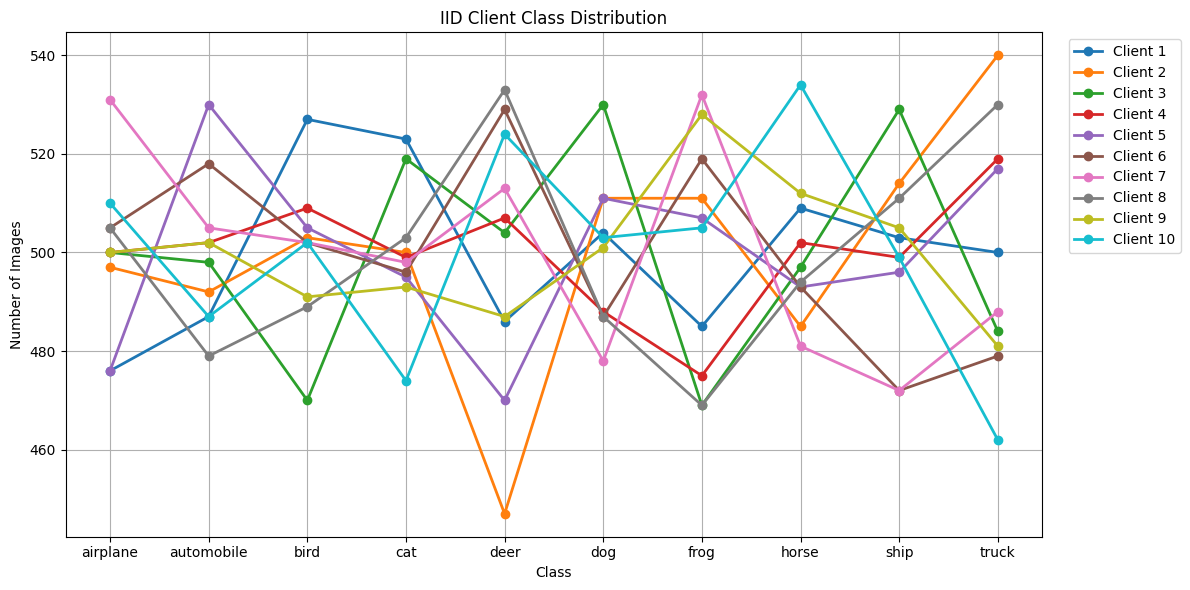

In [12]:
# ============================================================
# VISUALIZE IID DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

for client in range(NUM_CLIENTS):

    plt.plot(
        range(10),
        client_distribution[client],
        marker='o',
        linewidth=2,
        label=f'Client {client+1}'
    )

plt.xticks(range(10), classes)

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.title("IID Client Class Distribution")

plt.grid(True)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()

## Understanding IID Partitioning

In Federated Learning, an IID (Independent and Identically Distributed) partition assumes that every client receives a random subset of the global dataset.

Characteristics:

- Equal number of samples per client
- Similar class distribution across all clients
- Minimal statistical heterogeneity
- Often used as the baseline for Federated Learning experiments

Although IID assumptions simplify model training, they rarely represent real-world scenarios where clients naturally collect different types of data.

# Dirichlet Non-IID Partitioning

In real-world Federated Learning, clients rarely possess identically distributed data.

Different users naturally generate different types of data, resulting in statistical heterogeneity.

To simulate this realistic scenario, we use a Dirichlet distribution to partition the dataset among clients.

The concentration parameter (α) controls the level of heterogeneity:

- Large α → Nearly IID distribution
- Small α → Highly Non-IID distribution

For this experiment, we use α = 0.3 to generate realistic client data distributions.

In [14]:
# ============================================================
# DIRICHLET NON-IID PARTITION FUNCTION
# ============================================================

def dirichlet_partition(targets, num_clients=10, alpha=0.3):

    targets = np.array(targets)

    num_classes = len(np.unique(targets))

    client_indices = [[] for _ in range(num_clients)]

    for cls in range(num_classes):

        class_indices = np.where(targets == cls)[0]

        np.random.shuffle(class_indices)

        proportions = np.random.dirichlet(
            np.repeat(alpha, num_clients)
        )

        split_points = (
            np.cumsum(proportions) * len(class_indices)
        ).astype(int)[:-1]

        split_indices = np.split(class_indices, split_points)

        for client_id, idx in enumerate(split_indices):
            client_indices[client_id].extend(idx)

    return client_indices

In [15]:
# ============================================================
# CREATE NON-IID CLIENTS
# ============================================================

ALPHA = 0.3

noniid_clients = dirichlet_partition(
    trainset.targets,
    num_clients=10,
    alpha=ALPHA
)

print("=" * 60)
print("DIRICHLET NON-IID PARTITIONS CREATED")
print("=" * 60)

for i, client in enumerate(noniid_clients):
    print(f"Client {i+1}: {len(client)} images")

DIRICHLET NON-IID PARTITIONS CREATED
Client 1: 4669 images
Client 2: 1418 images
Client 3: 6651 images
Client 4: 5060 images
Client 5: 3687 images
Client 6: 2779 images
Client 7: 7831 images
Client 8: 7645 images
Client 9: 5932 images
Client 10: 4328 images


In [16]:
# ============================================================
# NON-IID CLASS DISTRIBUTION
# ============================================================

targets = np.array(trainset.targets)

noniid_distribution = []

for client in noniid_clients:

    labels = targets[client]

    counts = [np.sum(labels == i) for i in range(10)]

    noniid_distribution.append(counts)

noniid_distribution = np.array(noniid_distribution)

for i in range(NUM_CLIENTS):
    print(f"Client {i+1}: {noniid_distribution[i]}")

Client 1: [ 446   20  923   81  566   39 1004  825  764    1]
Client 2: [  3   0  10 879   0  35 481   3   7   0]
Client 3: [  18    0    2  127  189 3896    0 1333  995   91]
Client 4: [  15 2284  195 2030   10    1    2    7    0  516]
Client 5: [ 315  818  270    6  723  108 1042   17  330   58]
Client 6: [   0   37   19  214  742    1  683 1023   33   27]
Client 7: [  79 1147   47    0  205  714 1358  898  166 3217]
Client 8: [3286    1 1870  500  608    0  424  105  841   10]
Client 9: [ 700   20 1659  461 1588   53    4  464  149  834]
Client 10: [ 138  673    5  702  369  153    2  325 1715  246]


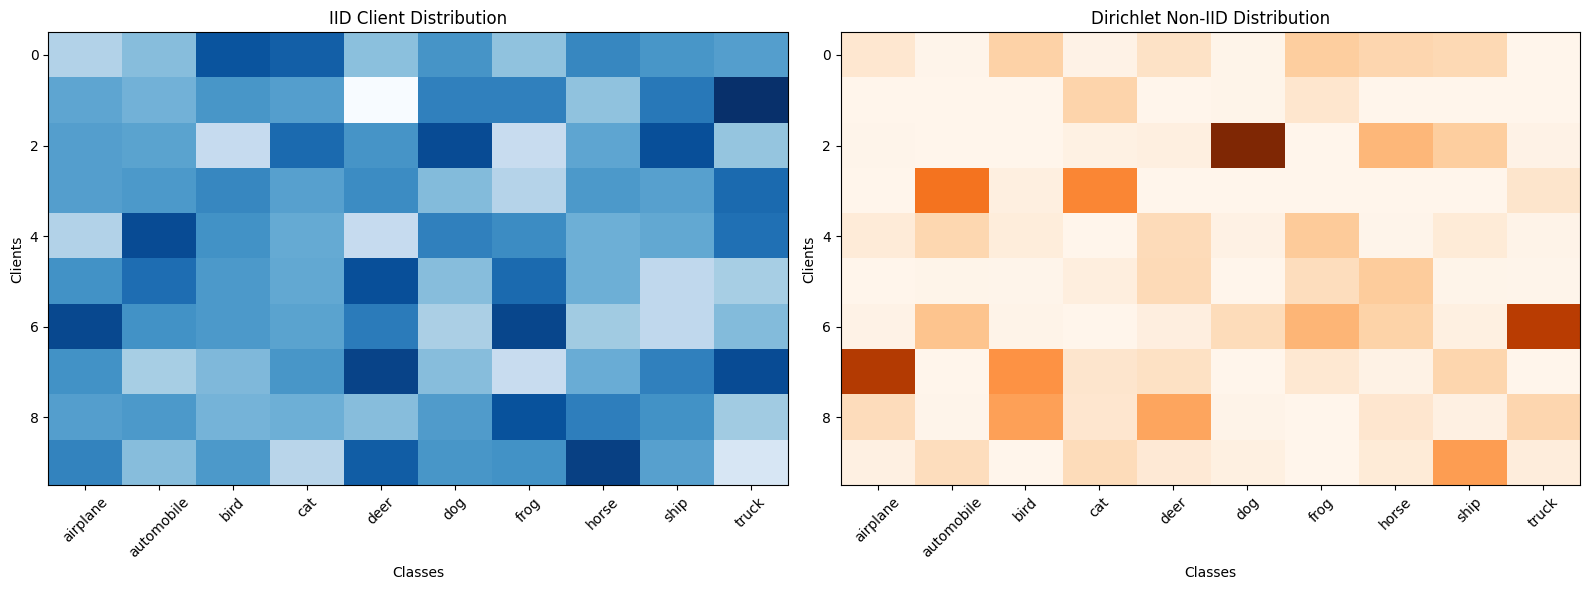

In [17]:
# ============================================================
# COMPARISON OF IID VS NON-IID
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(client_distribution, aspect='auto', cmap='Blues')
axes[0].set_title("IID Client Distribution")
axes[0].set_xlabel("Classes")
axes[0].set_ylabel("Clients")
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(classes, rotation=45)

axes[1].imshow(noniid_distribution, aspect='auto', cmap='Oranges')
axes[1].set_title("Dirichlet Non-IID Distribution")
axes[1].set_xlabel("Classes")
axes[1].set_ylabel("Clients")
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(classes, rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# SAVE CLIENT PARTITIONS
# ============================================================

import os
import pickle

# Create directory if it doesn't exist
os.makedirs("saved_partitions", exist_ok=True)

# Save IID partitions
with open("saved_partitions/iid_clients.pkl", "wb") as f:
    pickle.dump(iid_clients, f)

# Save Non-IID partitions
with open("saved_partitions/noniid_clients.pkl", "wb") as f:
    pickle.dump(noniid_clients, f)

print("=" * 60)
print("Partitions successfully saved!")
print("Location: saved_partitions/")
print("=" * 60)

Partitions successfully saved!
Location: saved_partitions/


In [19]:
# ============================================================
# VERIFY SAVED PARTITIONS
# ============================================================

print("Saved files:")

for file in os.listdir("saved_partitions"):
    print("✓", file)

Saved files:
✓ noniid_clients.pkl
✓ iid_clients.pkl


In [20]:
# ============================================================
# NOTEBOOK SUMMARY
# ============================================================

print("=" * 60)
print("NOTEBOOK 02 COMPLETED")
print("=" * 60)

print("✓ CIFAR-10 dataset loaded")
print("✓ Data preprocessing completed")
print("✓ Dataset explored and visualized")
print("✓ IID client partition created")
print("✓ Dirichlet Non-IID partition created")
print("✓ Client distributions analyzed")
print("✓ Partitions saved for future experiments")

NOTEBOOK 02 COMPLETED
✓ CIFAR-10 dataset loaded
✓ Data preprocessing completed
✓ Dataset explored and visualized
✓ IID client partition created
✓ Dirichlet Non-IID partition created
✓ Client distributions analyzed
✓ Partitions saved for future experiments


# Notebook 02 Complete

## Key Achievements

This notebook established the data preparation pipeline for all subsequent Federated Learning experiments.

### Completed Tasks

- Loaded and preprocessed the CIFAR-10 dataset
- Explored dataset structure and class distribution
- Created IID client partitions
- Simulated realistic Non-IID client partitions using a Dirichlet distribution (α = 0.3)
- Compared IID and Non-IID data distributions through visualizations
- Saved partition indices for reproducible experiments

## Importance

The generated client partitions will be reused throughout the remaining notebooks, ensuring that every training strategy is evaluated under identical data conditions. This consistency is essential for fair comparison of Federated Learning algorithms and privacy-preserving techniques.

### Next Notebook

**Notebook 03 — CNN Model Development & Local Client Training**

In the next stage, we will:

- Design a CNN classifier for CIFAR-10
- Train models on individual clients
- Evaluate local model performance
- Prepare the foundation for Federated Averaging (FedAvg)